# Mapping Light Echoes with U-Net

## Overview

Light echoes are extended and diffuse structures produced when light from a transient event scatters off surrounding dust.
Because of their complex morphology and low surface brightness, automatically identifying and extracting light echoes from astronomical images is challenging.

In this notebook, we use a **U-Net convolutional neural network** to perform image segmentation of light echoes. U-Net is widely used for image segmentation. The skip connections between the encoder and decoder allow the model to preserve fine spatial details while learning high-level features. For light echoes, U-Net provides a way to automatically map diffuse and irregular structures that are difficult to identify using traditional image processing methods.


The goal is to train a model that learns the spatial patterns of light echoes and produces a pixel-level mask that separates the echo structures from the background.


The workflow includes:

**Prepare the dataset**
   - Load astronomical images containing light echoes.
   - Load corresponding segmentation masks.

**Build the U-Net model**
   - Use an encoder-decoder architecture.
   - The encoder learns image features and spatial structures.
   - The decoder reconstructs a pixel-level segmentation map.

**Train the segmentation model**
   - Compare predicted masks with ground-truth masks.
   - Optimize the model using segmentation losses.
   - Monitor training and validation performance.

**Evaluate the model**
   - Visualize predicted masks.
   - Compare predictions with the true light echo structures.
   - Measure segmentation accuracy.



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# change path
cd /content/drive/MyDrive/ztf_summer_school_2026/day3/le_study/


/content/drive/MyDrive/ztf_summer_school_2026


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage.io as io
from PIL import Image
#import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from pycocotools.coco import COCO

#from matplotlib.backends.backend_pdf import PdfPages

%matplotlib inline


In [ ]:
ls

dataset/  LEsim.ipynb  lstm.ipynb  unet.ipynb


## build mask


In [ ]:

coco = COCO("./dataset/LE_cand1_coco/annotations.json")



loading annotations into memory...
Done (t=1.47s)
creating index...
index created!


In [ ]:
# Load the categories in a variable
catIDs = coco.getCatIds()
cats = coco.loadCats(catIDs)
cats

[{'supercategory': None, 'id': 0, 'name': '_background_'},
 {'supercategory': None, 'id': 1, 'name': 'LE'},
 {'supercategory': None, 'id': 2, 'name': 'star'}]

In [ ]:
#img_id = 0
#ann_ids = coco.getAnnIds(imgIds=img_id)
#ann_info = coco.loadAnns(ann_ids)

img_id = coco.getImgIds()[1]
img_info = coco.loadImgs(img_id)[0]
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

In [ ]:
img_path = "./dataset/LE_cand1_coco/"

In [ ]:
ls './dataset/'LE_cand1_coco

annotations.json  JPEGImages/


array([[[ 90,  90,  90],
        [182, 182, 182],
        [231, 231, 231],
        ...,
        [230, 230, 230],
        [240, 240, 240],
        [245, 245, 245]],

       [[255, 255, 255],
        [235, 235, 235],
        [ 39,  39,  39],
        ...,
        [  8,   8,   8],
        [ 63,  63,  63],
        [104, 104, 104]],

       [[239, 239, 239],
        [247, 247, 247],
        [  0,   0,   0],
        ...,
        [  3,   3,   3],
        [255, 255, 255],
        [234, 234, 234]],

       ...,

       [[  0,   0,   0],
        [146, 146, 146],
        [ 59,  59,  59],
        ...,
        [ 72,  72,  72],
        [  3,   3,   3],
        [199, 199, 199]],

       [[ 15,  15,  15],
        [ 49,  49,  49],
        [ 25,  25,  25],
        ...,
        [197, 197, 197],
        [  1,   1,   1],
        [  0,   0,   0]],

       [[ 88,  88,  88],
        [168, 168, 168],
        [ 57,  57,  57],
        ...,
        [  2,   2,   2],
        [  0,   0,   0],
        [ 10,  10,  10]]], dtype=uint8)
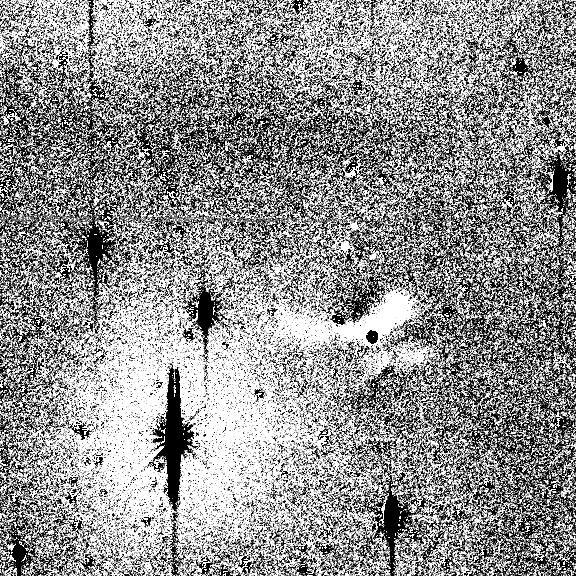

In [ ]:
image = io.imread(img_path + img_info["file_name"])

image

In [ ]:
mask.shape

(576, 576)

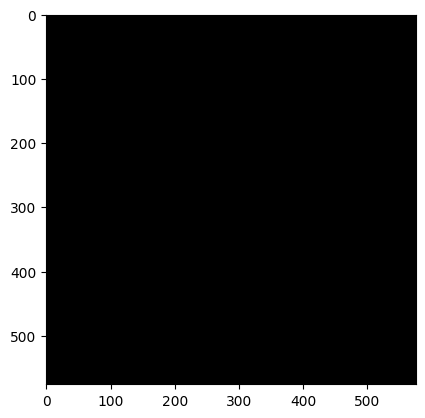

In [ ]:
plt.imshow(mask, cmap="gray")


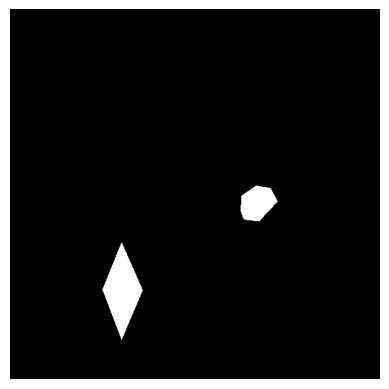

In [ ]:
# plot the mask

H = img_info["height"]
W = img_info["width"]

mask_all = np.zeros((H, W), dtype=np.uint8)

for ann in anns:
    #print(ann['id'])
    mask = coco.annToMask(ann)
    mask_all[mask == 1] = 1

plt.imshow(mask_all, cmap="gray")
plt.axis("off")
plt.show()

## Dataset

In [ ]:

class COCOSegmentationDataset(Dataset):
    def __init__(
        self,
        image_dir,
        ann_file,
        target_category_id=1,
        transform=None
    ):
        self.image_dir = image_dir
        self.coco = COCO(ann_file)
        self.img_ids = self.coco.getImgIds()

        self.target_category_id = target_category_id
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):

        img_id = self.img_ids[idx]

        # image info
        img_info = self.coco.loadImgs(img_id)[0]

        image_path = os.path.join(
            self.image_dir,
            img_info["file_name"]
        )

        # load image
        image = Image.open(image_path).convert("RGB")
        image = np.array(image)

        H, W = img_info["height"], img_info["width"]

        # binary mask
        mask = np.zeros((H, W), dtype=np.uint8)

        # annotations
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # keep ONLY category_id == 1 for light echoes
        for ann in anns:

            if ann["category_id"] != self.target_category_id:
                continue

            # skip invalid polygons
            if "segmentation" not in ann:
                continue

            try:
                m = self.coco.annToMask(ann)
                mask[m == 1] = 1

            except Exception:
                # skip broken annotations
                continue

        # augmentations
        if self.transform:
            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        # tensor conversion and normalization
        image = torch.tensor(image).permute(2, 0, 1).float() / 255.0

        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
dataset = COCOSegmentationDataset(image_dir="./dataset/LE_cand1_coco/", ann_file="./dataset/LE_cand1_coco/annotations.json")



loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [ ]:
len(dataset)

30

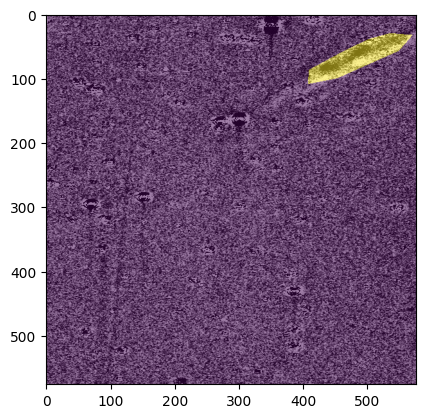

In [ ]:
image, mask = dataset[9]

# show image
plt.imshow(image[0, :, :], cmap='gray')

# show mask
plt.imshow(mask[0], alpha=.5)

## build the model

In [ ]:

# -----------------------
# 1. U-Net model
# -----------------------

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        self.out = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)              # [B, base, H, W]
        e2 = self.enc2(self.pool(e1))  # [B, 2base, H/2, W/2]
        e3 = self.enc3(self.pool(e2))  # [B, 4base, H/4, W/4]
        e4 = self.enc4(self.pool(e3))  # [B, 8base, H/8, W/8]

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [ ]:
dataset = COCOSegmentationDataset(
    image_dir="./dataset/LE_cand1_coco/",
    ann_file="./dataset/LE_cand1_coco/annotations.json",
    target_category_id=1
)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [ ]:
# split train/test
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size], generator=torch.Generator().manual_seed(0)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

In [ ]:
len(train_dataset), len(val_dataset)

(21, 9)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet(
    in_channels=3,
    out_channels=1,
    base=32
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def dice_score(pred, target, eps=1e-7):
    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * intersection + eps) / (union + eps)


def iou_score(pred, target, eps=1e-7):
    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + eps) / (union + eps)

### train the model

In [ ]:
num_epochs = 50

train_losses = []
val_losses = []
#val_dice_scores = []
val_iou_scores = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)

            probs = torch.sigmoid(logits)
            preds = probs > 0.5

            val_loss += loss.item()
            val_dice += dice_score(preds, masks).item()
            val_iou += iou_score(preds, masks).item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    #val_dice_scores.append(val_dice)
    val_iou_scores.append(val_iou)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Dice: {val_dice:.4f} "
        f"IoU: {val_iou:.4f}"
    )


Epoch [1/50] Train Loss: 0.7189 Val Loss: 0.6854 Dice: 0.0399 IoU: 0.0205
Epoch [2/50] Train Loss: 0.6868 Val Loss: 0.6963 Dice: 0.0592 IoU: 0.0309
Epoch [3/50] Train Loss: 0.6107 Val Loss: 2.1054 Dice: 0.0456 IoU: 0.0235
Epoch [4/50] Train Loss: 0.5398 Val Loss: 0.6197 Dice: 0.2984 IoU: 0.1870
Epoch [5/50] Train Loss: 0.5011 Val Loss: 0.5711 Dice: 0.4131 IoU: 0.2715
Epoch [6/50] Train Loss: 0.4685 Val Loss: 0.5024 Dice: 0.3013 IoU: 0.2048
Epoch [7/50] Train Loss: 0.4538 Val Loss: 0.5115 Dice: 0.3772 IoU: 0.2638
Epoch [8/50] Train Loss: 0.4359 Val Loss: 0.4129 Dice: 0.2157 IoU: 0.1330
Epoch [9/50] Train Loss: 0.4216 Val Loss: 0.4214 Dice: 0.3990 IoU: 0.2722
Epoch [10/50] Train Loss: 0.4074 Val Loss: 0.3942 Dice: 0.2829 IoU: 0.1941
Epoch [11/50] Train Loss: 0.3965 Val Loss: 0.7486 Dice: 0.3004 IoU: 0.1961
Epoch [12/50] Train Loss: 0.3898 Val Loss: 0.3953 Dice: 0.4232 IoU: 0.2974
Epoch [13/50] Train Loss: 0.3892 Val Loss: 1.0799 Dice: 0.2604 IoU: 0.1607
Epoch [14/50] Train Loss: 0.3840 V

**Exercise: plot the train_loss and val_loss**

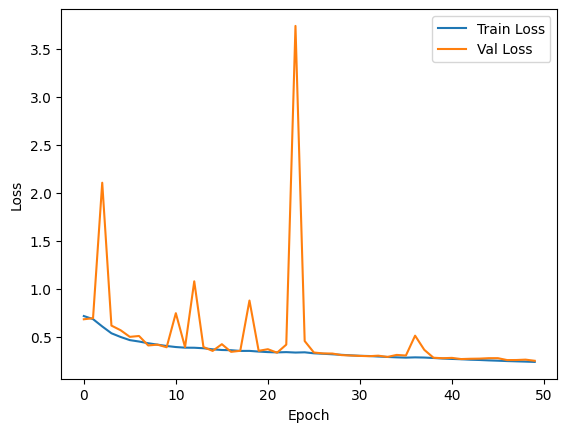

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
#plt.plot(val_iou_scores, label="Val IoU")
#plt.plot(val_dice_scores, label="Val Dice"
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### evaulation

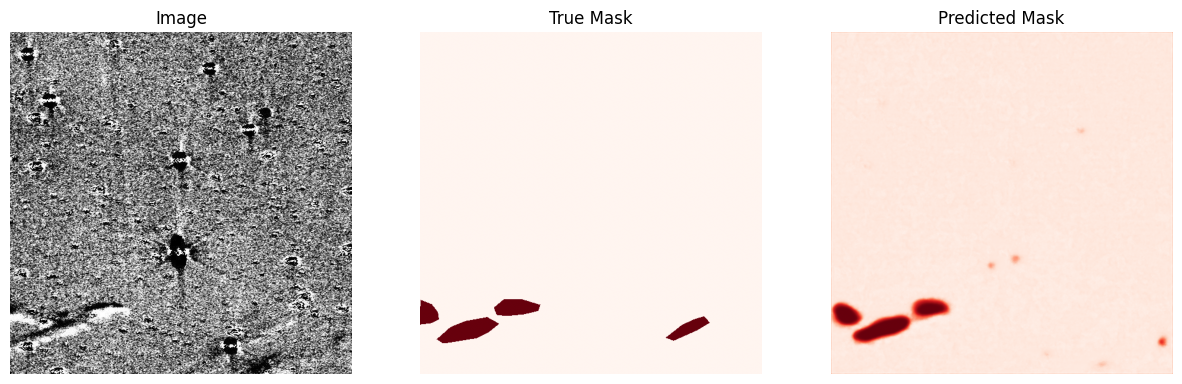

In [ ]:
model.eval()

idx = 8

image, mask = val_dataset[idx]

image = image.to(device)

with torch.no_grad():
    logits = model(image.unsqueeze(0))
    prob = torch.sigmoid(logits)
    pred_mask = prob[0, 0].cpu().numpy()

img_np = image.permute(1, 2, 0).cpu().numpy()
true_mask = mask[0].numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_mask, cmap="Reds")
plt.title("True Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
#plt.imshow(pred_mask > 0.5, cmap="gray")
plt.imshow(pred_mask, cmap="Reds")

plt.title("Predicted Mask")
plt.axis("off")

plt.show()

(np.float64(-0.5), np.float64(575.5), np.float64(575.5), np.float64(-0.5))

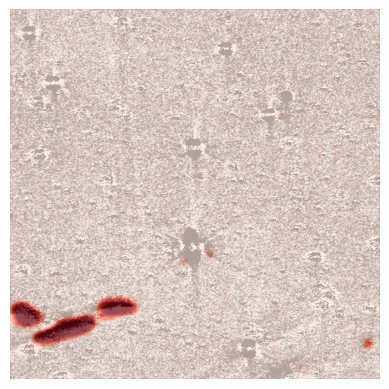

In [ ]:
plt.imshow(img_np, cmap="gray")
plt.imshow(pred_mask, cmap="Reds", alpha=0.7)
plt.axis("off")


 **Exercise: Evaluate the segmentation performance of U-Net by computing the IoU score on the train and validation dataset.**

